# Market Regime Detection — Hidden Markov Model

**Author:** Quantitative Research Portfolio  
**Model:** Gaussian Hidden Markov Model (HMM)  
**Assets:** META · TSLA · NIFTY 50 · NIFTY Bank  

---

### Objective

This notebook detects latent market regimes using a **Gaussian Hidden Markov Model** — a sequential probabilistic model that explicitly accounts for the time-ordered nature of financial data. It serves as the advanced model in this project, directly comparable to the K-Means baseline.

### What is a Hidden Markov Model?

An HMM assumes the market is always in one of *n* unobservable (hidden) states. What we observe — returns, volatility, drawdown — are **emissions** from those states. The model simultaneously learns:

| Parameter | What it encodes |
|---|---|
| Emission distributions | What each regime looks like in feature space |
| **Transition matrix** | How likely it is to move between regimes — **learned during training** |
| Initial distribution | Probability of starting in each state |

Training uses **Baum-Welch** (Expectation-Maximisation). Decoding uses the **Viterbi algorithm** to find the most likely state sequence.

### Why HMM vs K-Means?

| Property | K-Means | HMM |
|---|---|---|
| Time ordering | Ignored | Core to the model |
| Transition probabilities | Post-hoc empirical | **Learned during training** |
| Regime assignment | Hard (0 or 1) | Soft — probability per state per day |
| Uncertainty quantification | Not available | ✅ Posterior probability bands |
| Next-day prediction | Not possible | ✅ Via transition matrix |
| Industry usage | Portfolio attribution | Risk systems, volatility targeting |

---
## 0 · Install & Import

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import yfinance as yf
from arch import arch_model
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

plt.style.use('dark_background')
sns.set_style('darkgrid')
sns.set_context('talk')

COLOR_MAP    = {'Bull': '#2ca02c', 'Correction': '#1f77b4', 'Crash': '#d62728'}
REGIME_ORDER = ['Bull', 'Correction', 'Crash']

print('✓ All imports successful')

✓ All imports successful


---
## 1 · Configuration

Change `SYMBOL` here to run the full analysis on a different asset.

In [2]:
# ── CONFIG — change SYMBOL to switch asset ───────────────────────────────────
SYMBOL   = 'META'       # Options: 'META', 'TSLA', '^NSEI', '^NSEBANK'
PERIOD   = '10y'
N_STATES = 3
SEED     = 42

NAMES = {
    'META': 'Meta Platforms', 'TSLA': 'Tesla',
    '^NSEI': 'NIFTY 50',      '^NSEBANK': 'NIFTY Bank'
}
NAME = NAMES.get(SYMBOL, SYMBOL)

print(f'Asset    : {NAME} ({SYMBOL})')
print(f'Period   : {PERIOD}')
print(f'N states : {N_STATES}')

Asset    : Meta Platforms (META)
Period   : 10y
N states : 3


---
## 2 · Data Download

In [3]:
raw = yf.download(SYMBOL, period=PERIOD, auto_adjust=True, progress=False)

if isinstance(raw.columns, pd.MultiIndex):
    col    = 'Close' if 'Close' in raw.columns.get_level_values(0) else raw.columns.get_level_values(0)[0]
    prices = raw.xs(col, level=0, axis=1).squeeze().dropna()
else:
    prices = raw['Close'].dropna() if 'Close' in raw.columns else raw.iloc[:, 0].dropna()

data = prices.to_frame(name='Close')

print(f'Rows       : {len(data):,}')
print(f'Date range : {data.index[0].date()} → {data.index[-1].date()}')

Rows       : 2,513
Date range : 2016-04-11 → 2026-04-08


---
## 3 · Feature Engineering

In [4]:
# Log returns
data['Return'] = np.log(data['Close'] / data['Close'].shift(1))

# GARCH(1,1) conditional volatility
returns_pct = data['Return'].dropna() * 100
garch_fit   = arch_model(returns_pct, vol='Garch', p=1, q=1).fit(disp='off')
data.loc[returns_pct.index, 'GARCH_vol'] = garch_fit.conditional_volatility / 100

# 20-day rolling realised volatility
data['Volatility'] = data['Return'].rolling(20).std()

# Percentage momentum — scale-independent
data['Momentum'] = data['Close'] / data['Close'].shift(20) - 1

# Drawdown from rolling all-time high
data['Rolling_Max'] = data['Close'].cummax()
data['Drawdown']    = (data['Close'] - data['Rolling_Max']) / data['Rolling_Max']

data = data.dropna().copy()

print(f'Features engineered. Final shape: {data.shape}')
data[['Return', 'GARCH_vol', 'Volatility', 'Momentum', 'Drawdown']].describe().round(5)

Features engineered. Final shape: (2493, 7)


,Return,GARCH_vol,Volatility,Momentum,Drawdown
count,2493.00000,2493.00000,2493.00000,2493.00000,2493.00000
mean,0.00066,0.02440,0.02144,0.01847,-0.15886
std,0.02451,0.01099,0.01193,0.09972,0.17681
min,-0.30639,0.01502,0.00440,-0.37161,-0.76736
25%,-0.00959,0.01844,0.01392,-0.03385,-0.21056
50%,0.00091,0.02120,0.01833,0.02293,-0.10327
75%,0.01225,0.02623,0.02594,0.07220,-0.02638
max,0.20931,0.15197,0.07718,0.48206,0.00000


---
## 4 · Price History

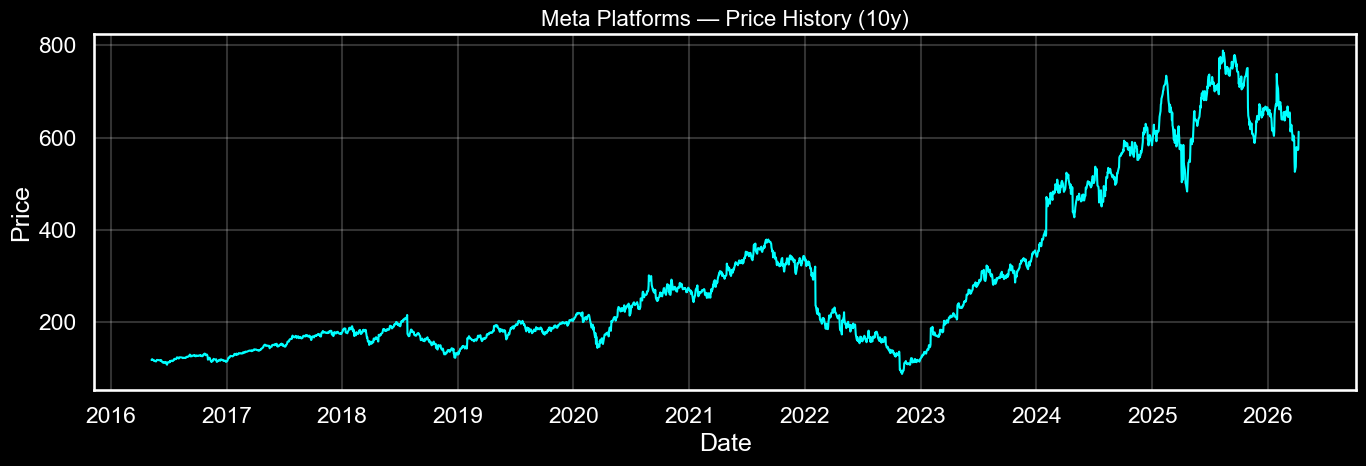

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(data.index, data['Close'], color='#00FFFF', linewidth=1.5)
ax.set_title(f'{NAME} — Price History ({PERIOD})', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(alpha=0.2)
plt.style.use('dark_background')
plt.tight_layout()
plt.show()

---
## 5 · Model Selection — How Many Hidden States?

HMM does not use silhouette or elbow — instead we use **AIC** and **BIC** (information criteria). Both penalise model complexity. Lower is better. We choose the number of states that minimises both, while also considering financial interpretability.

  States 2 | AIC: 56,338,129.2 | BIC: 56,338,268.9
  States 3 | AIC: 47,005,737.3 | BIC: 47,005,964.3
  States 4 | AIC: 45,660,119.0 | BIC: 45,660,445.0
  States 5 | AIC: 39,172,181.3 | BIC: 39,172,617.9
  States 6 | AIC: 35,805,189.3 | BIC: 35,805,748.2


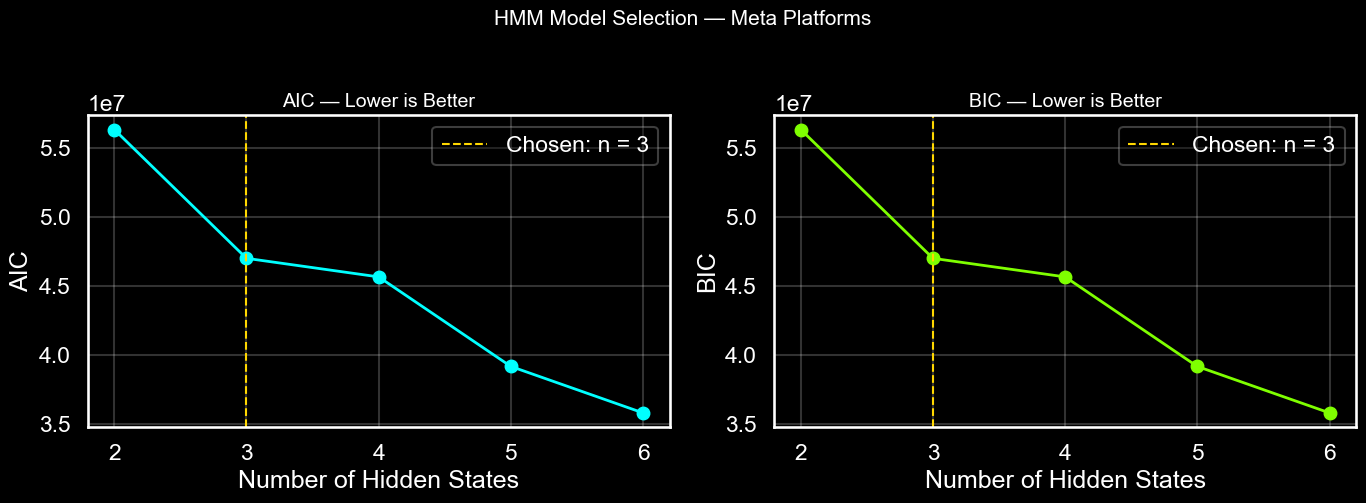


AIC/BIC may favour more than 3 states statistically.
n=3 is chosen for financial interpretability: Bull / Correction / Crash is actionable.
This is a deliberate, documented modelling decision — not an oversight.


In [6]:
FEATURE_COLS = ['Return', 'GARCH_vol', 'Volatility', 'Momentum', 'Drawdown']

scaler = StandardScaler()
X      = scaler.fit_transform(data[FEATURE_COLS])

T, d        = X.shape
state_range = range(2, 7)
aic_scores  = []
bic_scores  = []

for n in state_range:
    hmm = GaussianHMM(n_components=n, covariance_type='full',
                      n_iter=200, random_state=SEED)
    hmm.fit(X)
    ll    = hmm.score(X)
    n_par = n * n + n * d + n * d
    aic_scores.append(2 * n_par - 2 * ll * T)
    bic_scores.append(n_par * np.log(T) - 2 * ll * T)
    print(f'  States {n} | AIC: {aic_scores[-1]:,.1f} | BIC: {bic_scores[-1]:,.1f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(state_range, aic_scores, 'o-', color='#00FFFF', linewidth=2, markersize=9)
ax1.axvline(x=N_STATES, color='#FFD700', linestyle='--',
            linewidth=1.5, label=f'Chosen: n = {N_STATES}')
ax1.set_title('AIC — Lower is Better', fontsize=14)
ax1.set_xlabel('Number of Hidden States')
ax1.set_ylabel('AIC')
ax1.legend(framealpha=0.3)
ax1.grid(alpha=0.2)

ax2.plot(state_range, bic_scores, 'o-', color='#7FFF00', linewidth=2, markersize=9)
ax2.axvline(x=N_STATES, color='#FFD700', linestyle='--',
            linewidth=1.5, label=f'Chosen: n = {N_STATES}')
ax2.set_title('BIC — Lower is Better', fontsize=14)
ax2.set_xlabel('Number of Hidden States')
ax2.set_ylabel('BIC')
ax2.legend(framealpha=0.3)
ax2.grid(alpha=0.2)

plt.suptitle(f'HMM Model Selection — {NAME}', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print()
print('AIC/BIC may favour more than 3 states statistically.')
print('n=3 is chosen for financial interpretability: Bull / Correction / Crash is actionable.')
print('This is a deliberate, documented modelling decision — not an oversight.')

---
## 6 · Fit the Gaussian HMM

**Covariance type: `full`** — each hidden state has its own full covariance matrix, allowing the model to capture correlated feature movements within each regime.

In [7]:
hmm_model = GaussianHMM(
    n_components    = N_STATES,
    covariance_type = 'full',
    n_iter          = 500,
    random_state    = SEED
)
hmm_model.fit(X)

# Viterbi decoding — most likely state sequence given observations
hidden_states      = hmm_model.predict(X)
data['HMM_Regime'] = hidden_states

# Posterior probabilities — P(state | all observations)
state_probs = hmm_model.predict_proba(X)
for i in range(N_STATES):
    data[f'Prob_State_{i}'] = state_probs[:, i]

print(f'Model converged : {hmm_model.monitor_.converged}')
print(f'Log-likelihood  : {hmm_model.score(X):,.4f}')
print()
print('Raw state distribution:')
for s in range(N_STATES):
    count = (hidden_states == s).sum()
    print(f'  State {s}: {count:,} days ({count/len(hidden_states):.1%})')

Model converged : True
Log-likelihood  : -9,427.5289

Raw state distribution:
  State 0: 775 days (31.1%)
  State 1: 1,100 days (44.1%)
  State 2: 618 days (24.8%)


---
## 7 · Auto-Label Regimes

Same conflict-free labeling logic as the KMeans notebook — labels are derived from empirical statistics, not hardcoded.

In [8]:
stats = data.groupby('HMM_Regime').agg(
    mean_return=('Return',    'mean'),
    mean_vol   =('Volatility','mean')
)
stats.index        = stats.index.astype(int)
data['HMM_Regime'] = data['HMM_Regime'].astype(int)

bull       = int(stats['mean_return'].idxmax())
remaining  = stats.drop(index=bull)
crash      = int(remaining['mean_vol'].idxmax())
correction = int([r for r in stats.index if r not in [bull, crash]][0])

regime_labels      = {bull: 'Bull', crash: 'Crash', correction: 'Correction'}
data['HMM_Label']  = data['HMM_Regime'].map(regime_labels)
state_label_map    = {v: k for k, v in regime_labels.items()}  # label → state index

if stats.loc[bull, 'mean_return'] < 0:
    print('⚠️  Warning: Bull regime has negative returns — inspect outputs carefully')

print('HMM Regime mapping:', regime_labels)
print()
print('Cluster statistics:')
print(stats.round(6))

HMM Regime mapping: {0: 'Bull', 2: 'Crash', 1: 'Correction'}

Cluster statistics:
            mean_return  mean_vol
HMM_Regime                       
0              0.001898  0.012806
1             -0.000032  0.019560
2              0.000333  0.035606


---
## 8 · Learned Transition Matrix

This is the defining advantage of HMM over K-Means. The transition matrix is a **core model parameter** — learned from data during Baum-Welch training, not computed after the fact.

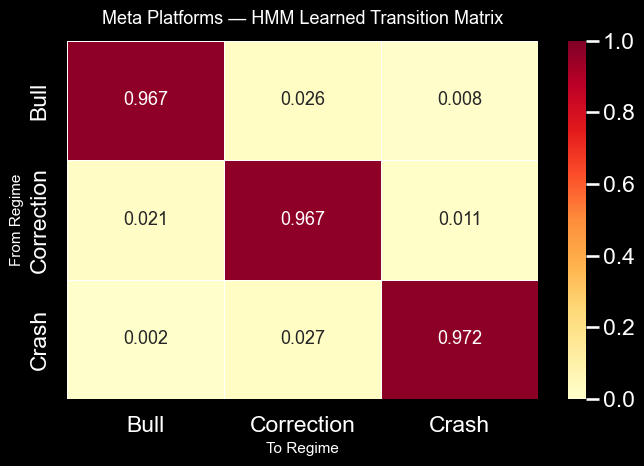

Learned Transition Matrix:
              Bull  Correction   Crash
Bull        0.9666      0.0256  0.0078
Correction  0.0215      0.9671  0.0114
Crash       0.0015      0.0268  0.9717

Diagonal  = regime persistence probability (learned, not post-hoc)
Off-diag  = probability of switching to another regime tomorrow

Stationary Distribution (long-run time in each regime):
  Bull        : 29.7%
  Correction  : 44.3%
  Crash       : 26.0%


In [9]:
state_order = [state_label_map[l] for l in REGIME_ORDER]

trans_df = pd.DataFrame(
    hmm_model.transmat_[np.ix_(state_order, state_order)],
    index=REGIME_ORDER, columns=REGIME_ORDER
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(trans_df, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            annot_kws={'size': 13})
ax.set_title(f'{NAME} — HMM Learned Transition Matrix', fontsize=13, pad=12)
ax.set_xlabel('To Regime',   fontsize=11)
ax.set_ylabel('From Regime', fontsize=11)
plt.tight_layout()
plt.show()

print('Learned Transition Matrix:')
print(trans_df.round(4))
print()
print('Diagonal  = regime persistence probability (learned, not post-hoc)')
print('Off-diag  = probability of switching to another regime tomorrow')
print()

# Stationary distribution
evals, evecs = np.linalg.eig(hmm_model.transmat_.T)
stat         = evecs[:, np.argmax(evals)].real
stat         = stat / stat.sum()
print('Stationary Distribution (long-run time in each regime):')
for lbl in REGIME_ORDER:
    idx = state_label_map[lbl]
    print(f'  {lbl:<12}: {stat[idx]:.1%}')

---
## 9 · Regime Statistics Table

In [10]:
z = 2.33

var_by_regime = data.groupby('HMM_Label').apply(
    lambda x: -(x['Return'].mean() + z * x['Return'].std())
).rename('VaR_99').reset_index()
var_by_regime.columns = ['Regime_Label', 'VaR_99']

regime_run   = (data['HMM_Label'] != data['HMM_Label'].shift()).cumsum()
avg_duration = (data.groupby(['HMM_Label', regime_run])
                    .size()
                    .groupby(level=0).mean()
                    .rename('Avg_Duration').reset_index())
avg_duration.columns = ['Regime_Label', 'Avg_Duration']

summary = data.groupby('HMM_Label').agg(
    Return    =('Return',    'mean'),
    Volatility=('Volatility','mean'),
    GARCH_Vol =('GARCH_vol', 'mean'),
    Drawdown  =('Drawdown',  'mean'),
).reset_index().rename(columns={'HMM_Label': 'Regime_Label'})

summary = (summary
    .merge(var_by_regime,  on='Regime_Label')
    .merge(avg_duration,   on='Regime_Label')
    .sort_values('Return', ascending=False)
    .reset_index(drop=True))

summary.style \
    .format({
        'Return':     '{:.2%}',
        'Volatility': '{:.2%}',
        'GARCH_Vol':  '{:.2%}',
        'Drawdown':   '{:.2%}',
        'VaR_99':     '{:.2%}',
        'Avg_Duration':'{:.1f}',
    }) \
    .set_caption(f'📊 {NAME} — HMM Regime Summary') \
    .background_gradient(cmap='RdYlGn', subset=['Return']) \
    .background_gradient(cmap='Reds',   subset=['Volatility', 'GARCH_Vol']) \
    .background_gradient(cmap='Purples',subset=['VaR_99']) \
    .background_gradient(cmap='Greys',  subset=['Avg_Duration']) \
    .set_properties(**{'text-align': 'center', 'border': '1px solid #444', 'font-size': '12pt'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#111'), ('color', 'white'),
            ('font-weight', 'bold'), ('text-align', 'center'),
            ('border', '1px solid #444')]},
        {'selector': 'td', 'props': [('border', '1px solid #444')]},
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'), ('font-size', '15px'),
            ('font-weight', 'bold'), ('color', 'white')]},
    ])

,Regime_Label,Return,Volatility,GARCH_Vol,Drawdown,VaR_99,Avg_Duration
0,Bull,0.19%,1.28%,1.85%,-1.94%,-2.96%,29.8
1,Crash,0.03%,3.56%,3.47%,-39.31%,-9.33%,34.3
2,Correction,-0.00%,1.96%,2.28%,-12.55%,-4.47%,30.6


---
## 10 · Regime-Colored Price Chart

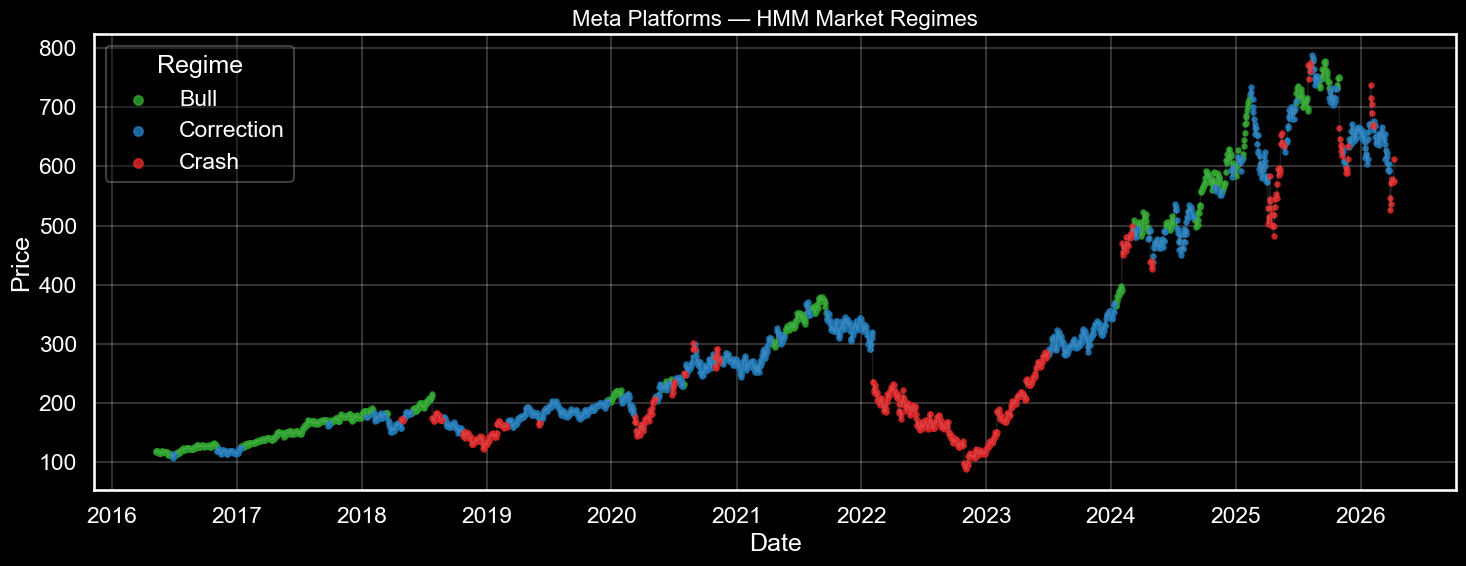

In [11]:
fig, ax = plt.subplots(figsize=(15, 6))

for label in REGIME_ORDER:
    sub = data[data['HMM_Label'] == label]
    ax.scatter(sub.index, sub['Close'],
               color=COLOR_MAP[label], label=label, s=10, alpha=0.85)

ax.plot(data.index, data['Close'], color='white', alpha=0.12, linewidth=1)
ax.set_title(f'{NAME} — HMM Market Regimes', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Regime', framealpha=0.3, markerscale=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

---
## 11 · State Probability Bands Over Time

This is **unique to HMM** — impossible with K-Means. Each panel shows the model's posterior probability of being in that regime on every trading day. Values near 1.0 indicate certainty; values between 0.3–0.7 represent genuine regime ambiguity that K-Means would force into a hard assignment.

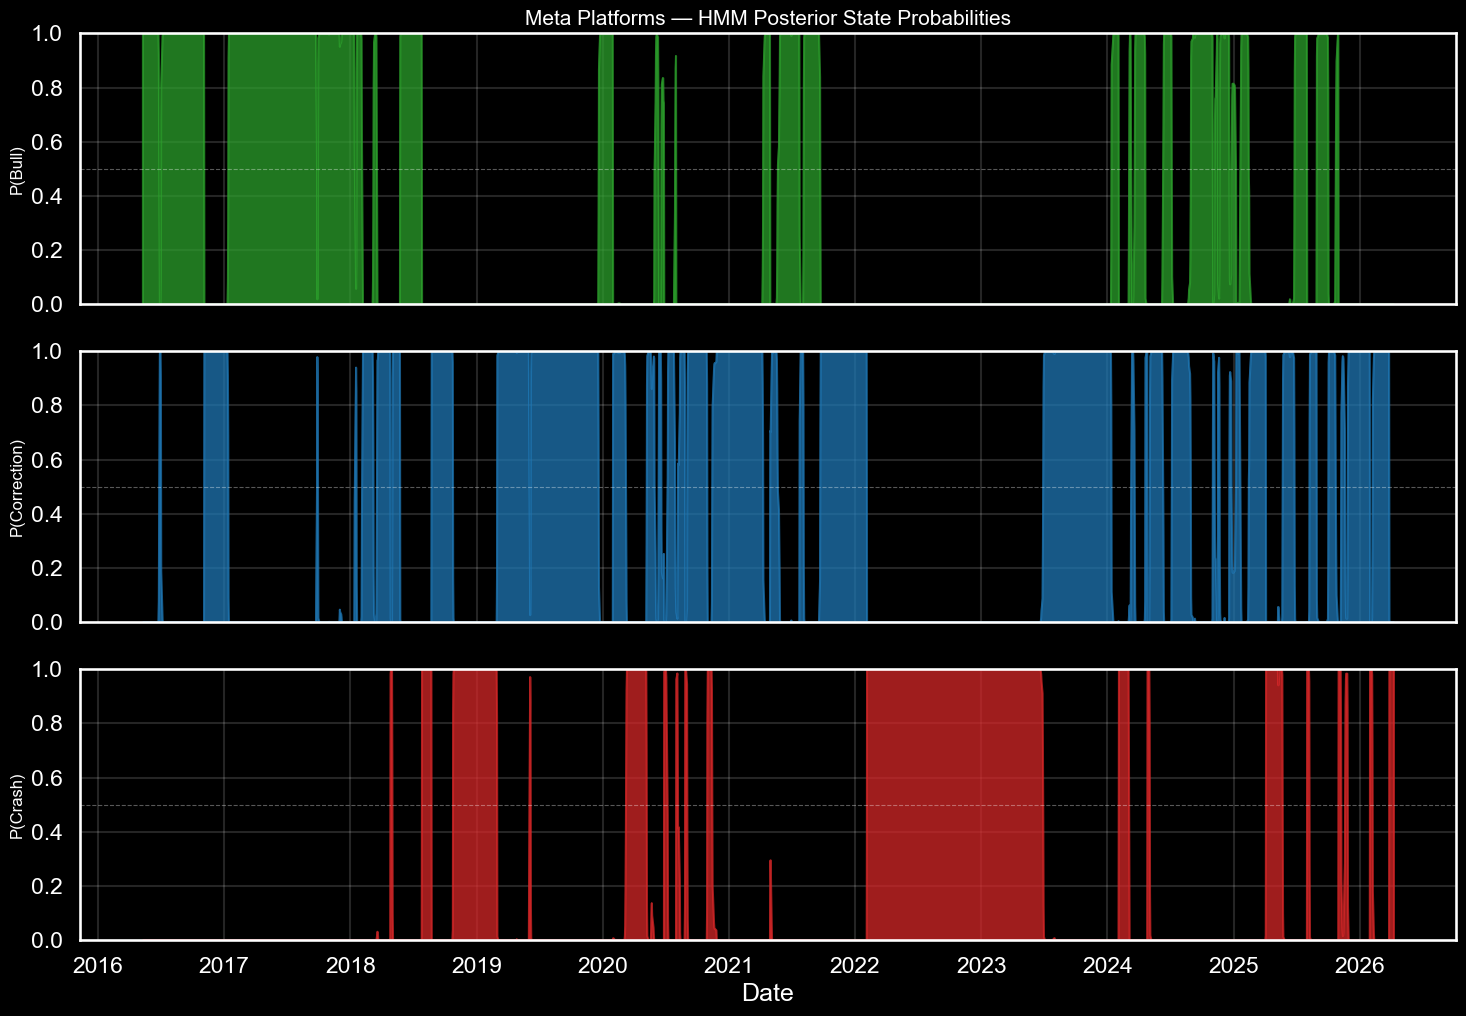

Solid bands  = model is highly confident in this regime (probability ≈ 1.0)
Fragmented   = genuine regime ambiguity — mixed signals in the feature space
K-Means collapses all of this uncertainty into a single hard label per day


In [12]:
plot_colors = ['#2ca02c', '#1f77b4', '#d62728']

fig, axes = plt.subplots(N_STATES, 1, figsize=(15, 3.5 * N_STATES), sharex=True)

for ax, label, color in zip(axes, REGIME_ORDER, plot_colors):
    idx = state_label_map[label]
    ax.fill_between(data.index, data[f'Prob_State_{idx}'],
                    alpha=0.75, color=color)
    ax.plot(data.index, data[f'Prob_State_{idx}'],
            color=color, linewidth=0.5, alpha=0.4)
    ax.axhline(y=0.5, color='white', linestyle='--', linewidth=0.8, alpha=0.35)
    ax.set_ylabel(f'P({label})', fontsize=12)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.15)

axes[0].set_title(f'{NAME} — HMM Posterior State Probabilities', fontsize=15)
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

print('Solid bands  = model is highly confident in this regime (probability ≈ 1.0)')
print('Fragmented   = genuine regime ambiguity — mixed signals in the feature space')
print('K-Means collapses all of this uncertainty into a single hard label per day')

---
## 12 · Regime Distribution

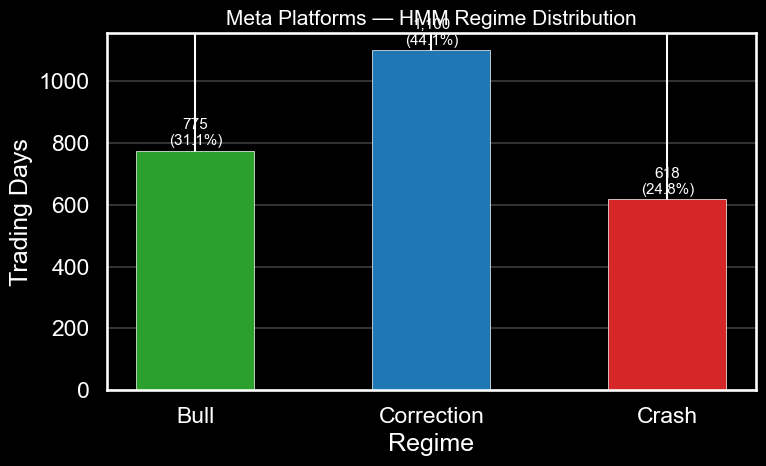

In [13]:
counts = data['HMM_Label'].value_counts().reindex(REGIME_ORDER)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values,
              color=[COLOR_MAP[l] for l in counts.index],
              edgecolor='white', linewidth=0.5, width=0.5)

for bar, count in zip(bars, counts.values):
    pct = count / len(data) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 8,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11)

ax.set_title(f'{NAME} — HMM Regime Distribution', fontsize=15)
ax.set_xlabel('Regime')
ax.set_ylabel('Trading Days')
ax.grid(alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

---
## 13 · Return Distributions Per Regime

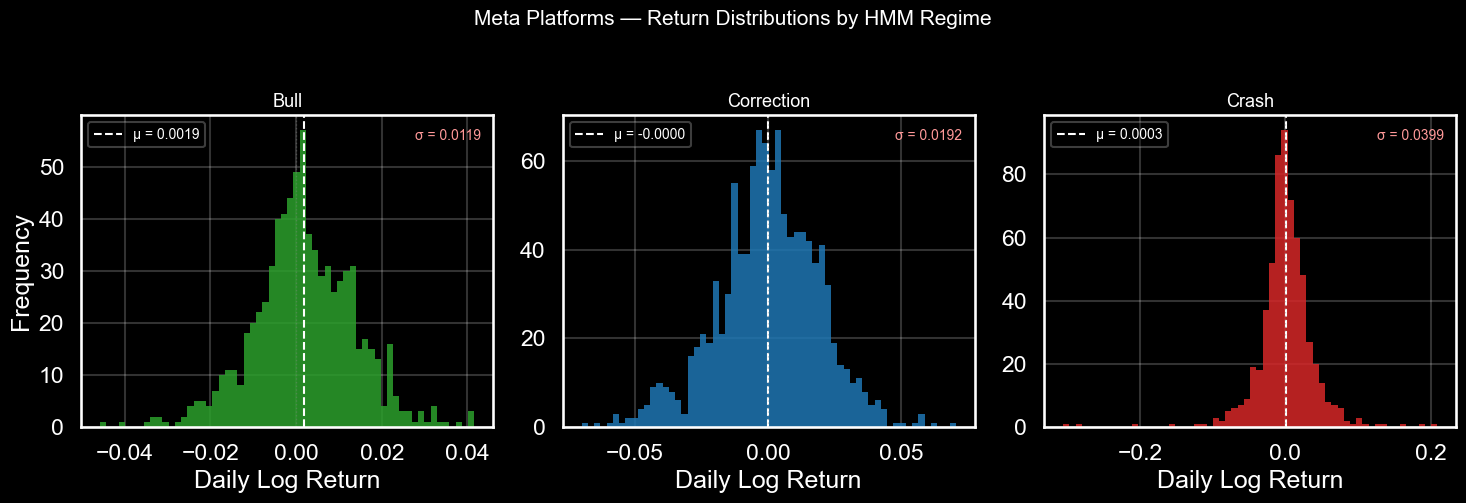

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#2ca02c', '#1f77b4', '#d62728']

for ax, label, color in zip(axes, REGIME_ORDER, colors):
    rets = data[data['HMM_Label'] == label]['Return']
    ax.hist(rets, bins=60, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(rets.mean(), color='white', linestyle='--',
               linewidth=1.5, label=f'μ = {rets.mean():.4f}')
    ax.axvline(0, color='grey', linestyle=':', linewidth=1, alpha=0.4)
    ax.set_title(f'{label}', fontsize=13)
    ax.set_xlabel('Daily Log Return')
    ax.legend(fontsize=10, framealpha=0.3)
    ax.grid(alpha=0.2)
    ax.text(0.97, 0.92, f'σ = {rets.std():.4f}',
            transform=ax.transAxes, ha='right', fontsize=10, color='#FF9999')

axes[0].set_ylabel('Frequency')
plt.suptitle(f'{NAME} — Return Distributions by HMM Regime', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---
## 14 · Regime Duration Analysis

HMM provides both empirical durations and **theoretical durations** derived analytically from the learned transition matrix: Expected duration = 1 / (1 − P(stay)). The close match between the two validates the model.

In [15]:
data['Regime_Change'] = (data['HMM_Label'] != data['HMM_Label'].shift()).cumsum()

durations = (data.groupby(['HMM_Label', 'Regime_Change'])
                 .size()
                 .groupby(level=0)
                 .agg(['mean','median','max','count'])
                 .rename(columns={'mean':'Avg Days','median':'Median',
                                  'max':'Max Days','count':'Episodes'})
                 .reindex(REGIME_ORDER))

# Theoretical from LEARNED transition matrix — unique to HMM
durations['Theoretical 1/(1−p)'] = [
    round(1 / (1 - trans_df.loc[lbl, lbl]), 1)
    for lbl in durations.index
]

print(f'Regime Duration Analysis — {NAME} (HMM)')
print('=' * 65)
print(durations.round(1).to_string())
print()
print('Theoretical 1/(1−p): derived from the LEARNED transition matrix persistence.')
print('Close match with Avg Days confirms the model has correctly captured dynamics.')

Regime Duration Analysis — Meta Platforms (HMM)
            Avg Days  Median  Max Days  Episodes  Theoretical 1/(1−p)
HMM_Label                                                            
Bull            29.8    18.0       176        26                 30.0
Correction      30.6    15.5       138        36                 30.4
Crash           34.3     6.0       351        18                 35.3

Theoretical 1/(1−p): derived from the LEARNED transition matrix persistence.
Close match with Avg Days confirms the model has correctly captured dynamics.


---
## 15 · Empirical vs Learned Transition Matrix

A model validation check. If the empirical matrix (computed from the Viterbi-decoded sequence) closely matches the learned matrix (from Baum-Welch training), the model has correctly captured the underlying dynamics.

In [16]:
data['Prev_Label'] = data['HMM_Label'].shift(1)
empirical_trans = pd.crosstab(
    data['Prev_Label'].dropna(),
    data.loc[data['Prev_Label'].notna(), 'HMM_Label'],
    normalize='index'
).reindex(index=REGIME_ORDER, columns=REGIME_ORDER, fill_value=0)

print('Empirical Transition Matrix (from decoded sequence):')
print(empirical_trans.round(4))
print()
print('Learned Transition Matrix (from Baum-Welch training):')
print(trans_df.round(4))
print()
diff = (empirical_trans - trans_df).abs().mean().mean()
print(f'Mean absolute difference: {diff:.4f}')
if diff < 0.01:
    print('✓ Excellent convergence — matrices are very close')
elif diff < 0.03:
    print('✓ Good convergence')
else:
    print('⚠️  Matrices differ — consider increasing n_iter')

Empirical Transition Matrix (from decoded sequence):
HMM_Label     Bull  Correction   Crash
Prev_Label                            
Bull        0.9665      0.0258  0.0077
Correction  0.0218      0.9673  0.0109
Crash       0.0016      0.0259  0.9724

Learned Transition Matrix (from Baum-Welch training):
              Bull  Correction   Crash
Bull        0.9666      0.0256  0.0078
Correction  0.0215      0.9671  0.0114
Crash       0.0015      0.0268  0.9717

Mean absolute difference: 0.0003
✓ Excellent convergence — matrices are very close


---
## 16 · Price vs Rolling VaR (99%)

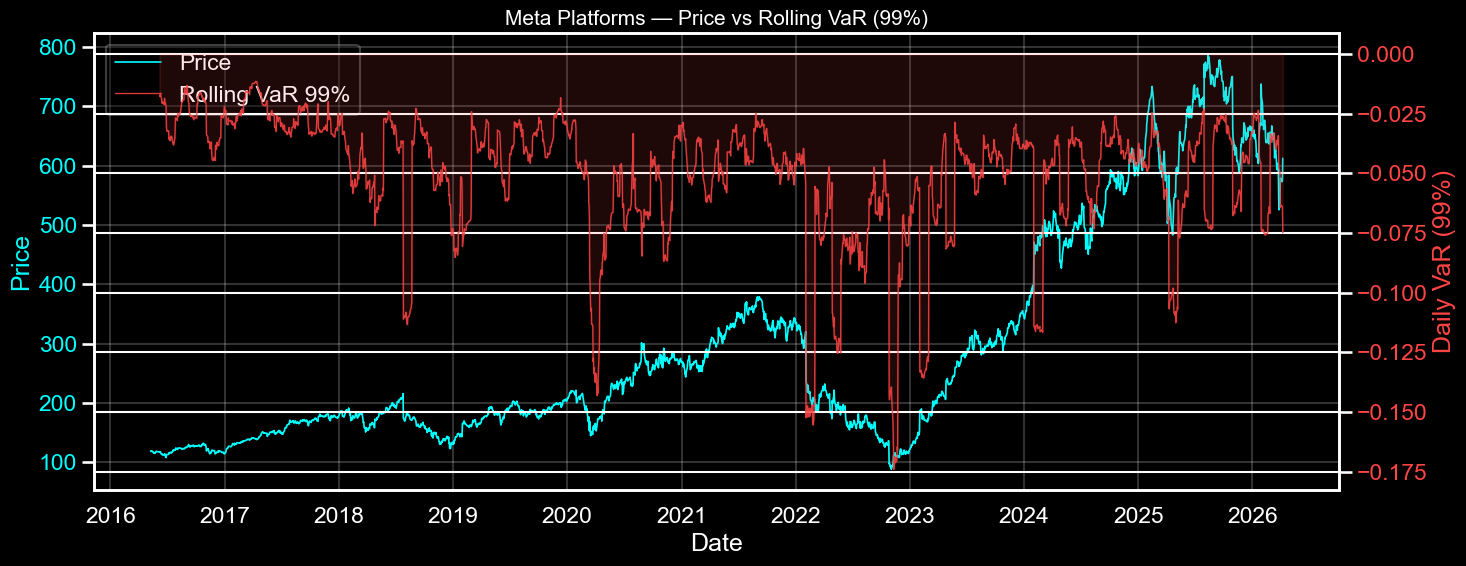

In [17]:
data['VaR_99'] = -(data['Return'].rolling(20).mean() + 2.33 * data['Volatility'])

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(data.index, data['Close'], color='#00FFFF',
         linewidth=1.2, label='Price')
ax1.set_ylabel('Price', color='#00FFFF')
ax1.tick_params(axis='y', labelcolor='#00FFFF')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(data.index, data['VaR_99'], color='#FF4444',
         linewidth=1, alpha=0.85, label='Rolling VaR 99%')
ax2.fill_between(data.index, data['VaR_99'], alpha=0.12, color='#FF4444')
ax2.set_ylabel('Daily VaR (99%)', color='#FF4444')
ax2.tick_params(axis='y', labelcolor='#FF4444')

lines  = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', framealpha=0.3)
ax1.set_title(f'{NAME} — Price vs Rolling VaR (99%)', fontsize=15)
ax1.set_xlabel('Date')
ax1.grid(alpha=0.2)
plt.tight_layout()
plt.show()

---
## 17 · Current Market Regime

In [18]:
latest        = data.iloc[-1]
current       = latest['HMM_Label']
current_date  = data.index[-1].date()
current_block = data['Regime_Change'].iloc[-1]
days_in       = (data['Regime_Change'] == current_block).sum()

print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  {NAME} ({SYMBOL})')
print(f'  As of          : {current_date}')
print(f'  Current Regime : {current}')
print(f'  Days in regime : {days_in}')
print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print()
print('Posterior state probabilities (today):')
for label in REGIME_ORDER:
    prob = latest[f'Prob_State_{state_label_map[label]}']
    bar  = '█' * int(prob * 28)
    print(f'  {label:<12}: {prob:5.1%}  {bar}')

print()
print('Next-day regime probabilities (from learned transition matrix):')
for to_label in REGIME_ORDER:
    prob = trans_df.loc[current, to_label]
    bar  = '█' * int(prob * 28)
    print(f'  → {to_label:<12}: {prob:5.1%}  {bar}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Meta Platforms (META)
  As of          : 2026-04-08
  Current Regime : Crash
  Days in regime : 9
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Posterior state probabilities (today):
  Bull        :  0.0%  
  Correction  :  0.1%  
  Crash       : 99.9%  ███████████████████████████

Next-day regime probabilities (from learned transition matrix):
  → Bull        :  0.2%  
  → Correction  :  2.7%  
  → Crash       : 97.2%  ███████████████████████████


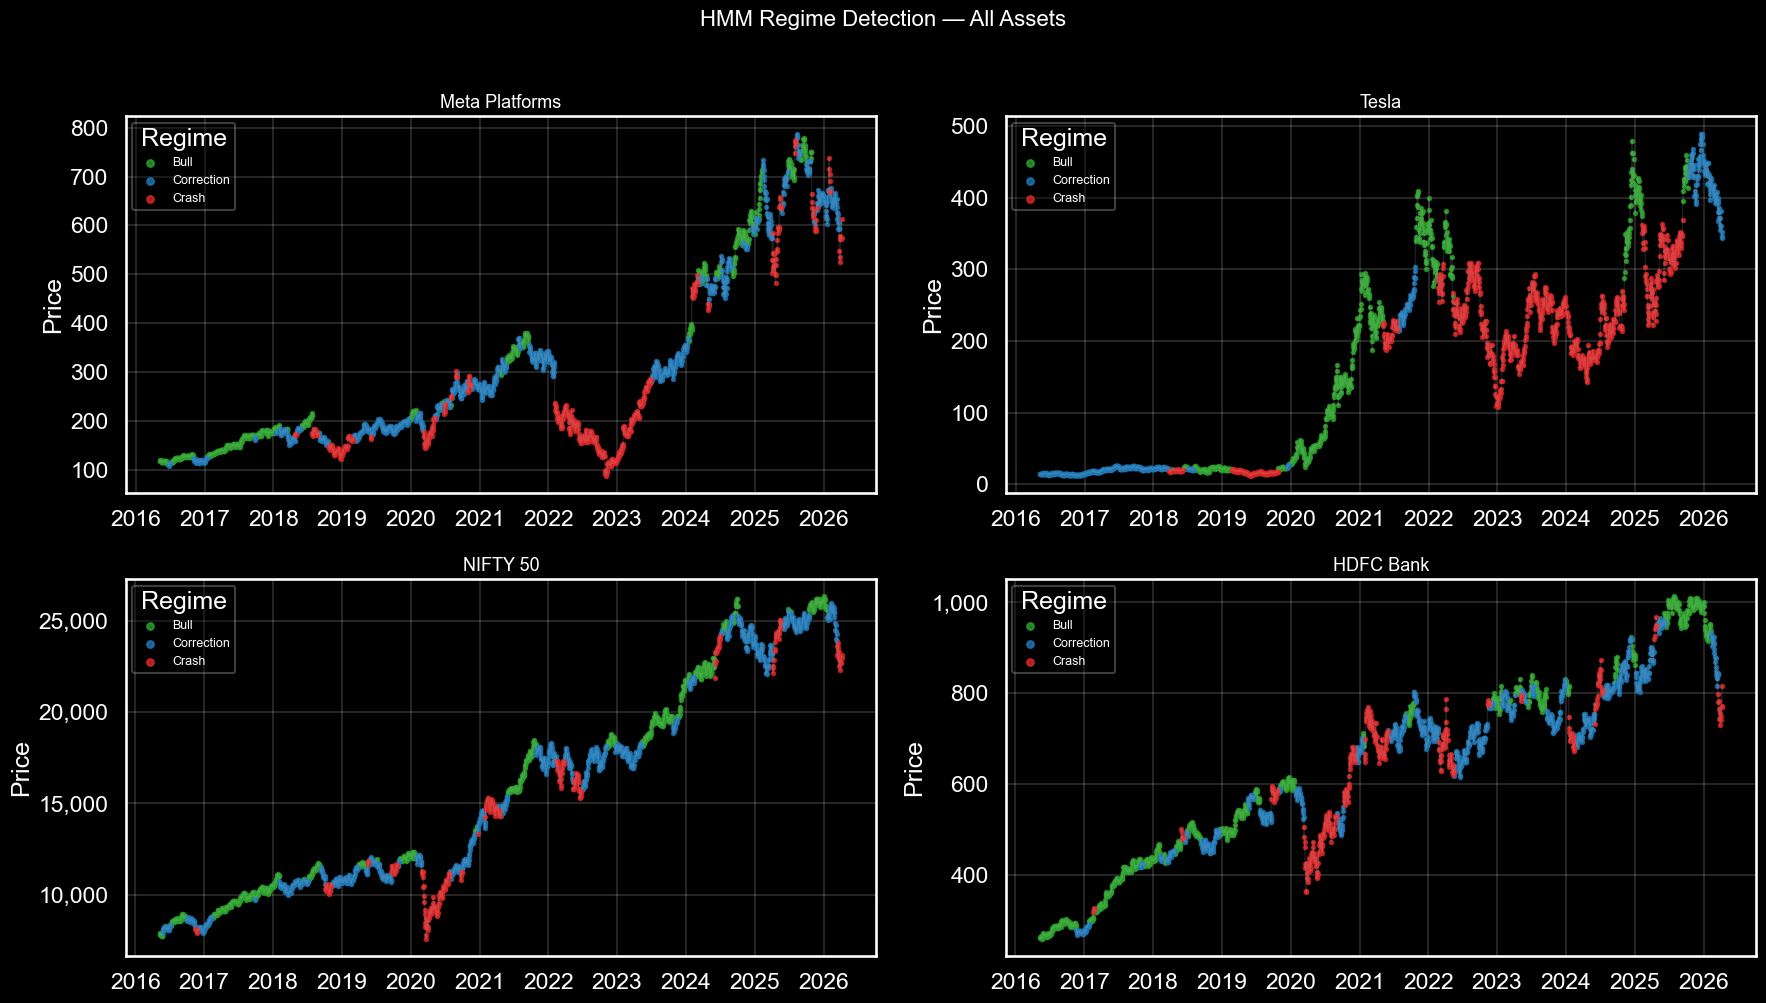

In [19]:
# ── Cross-Asset Regime Overview ──────────────────────────────────────────────
import yfinance as yf

ASSETS = {
    'META'    : 'Meta Platforms',
    'TSLA'    : 'Tesla',
    '^NSEI'   : 'NIFTY 50',
    'HDFCBANK.NS': 'HDFC Bank'
}

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax, (symbol, name) in zip(axes, ASSETS.items()):

    # Download & features
    raw = yf.download(symbol, period='10y', auto_adjust=True, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        col = 'Close' if 'Close' in raw.columns.get_level_values(0) else raw.columns.get_level_values(0)[0]
        px  = raw.xs(col, level=0, axis=1).squeeze().dropna()
    else:
        px = raw['Close'].dropna() if 'Close' in raw.columns else raw.iloc[:,0].dropna()

    d = px.to_frame(name='Close')
    d['Return']     = np.log(d['Close'] / d['Close'].shift(1))
    d['Volatility'] = d['Return'].rolling(20).std()
    d['Momentum']   = d['Close'] / d['Close'].shift(20) - 1
    d['Rolling_Max']= d['Close'].cummax()
    d['Drawdown']   = (d['Close'] - d['Rolling_Max']) / d['Rolling_Max']

    rpct    = d['Return'].dropna() * 100
    gfit    = arch_model(rpct, vol='Garch', p=1, q=1).fit(disp='off')
    d.loc[rpct.index, 'GARCH_vol'] = gfit.conditional_volatility / 100
    d = d.dropna().copy()

    # HMM
    hmm_feats = ['Return', 'GARCH_vol', 'Volatility', 'Momentum', 'Drawdown']
    Xs  = StandardScaler().fit_transform(d[hmm_feats])
    hmm = GaussianHMM(n_components=3, covariance_type='full',
                      n_iter=500, random_state=42)
    hmm.fit(Xs)
    d['HMM_Regime'] = hmm.predict(Xs).astype(int)

    # Auto-label
    st  = d.groupby('HMM_Regime').agg(mean_return=('Return','mean'), mean_vol=('Volatility','mean'))
    st.index = st.index.astype(int)
    b   = int(st['mean_return'].idxmax())
    cr  = int(st.drop(index=b)['mean_vol'].idxmax())
    co  = int([r for r in st.index if r not in [b, cr]][0])
    lbl = {b:'Bull', cr:'Crash', co:'Correction'}
    d['Regime_Label'] = d['HMM_Regime'].map(lbl)

    # Plot
    for label in ['Bull','Correction','Crash']:
        sub = d[d['Regime_Label'] == label]
        ax.scatter(sub.index, sub['Close'],
                   color=COLOR_MAP[label], label=label, s=6, alpha=0.8)

    ax.plot(d.index, d['Close'], color='white', alpha=0.12, linewidth=1)
    ax.set_title(name, fontsize=13)
    ax.set_ylabel('Price')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(title='Regime', fontsize=9, markerscale=2, framealpha=0.3)
    ax.grid(alpha=0.15)

plt.suptitle('HMM Regime Detection — All Assets', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---
## 18 · Key Findings Summary

In [20]:
bull_row  = summary[summary['Regime_Label'] == 'Bull'].iloc[0]
corr_row  = summary[summary['Regime_Label'] == 'Correction'].iloc[0]
crash_row = summary[summary['Regime_Label'] == 'Crash'].iloc[0]

print(f'{'═'*60}')
print(f'  HMM REGIME SUMMARY — {NAME}')
print(f'{'═'*60}')
print(f'  Model      : Gaussian HMM | n_states={N_STATES} | n_features={len(FEATURE_COLS)}')
print(f'  Converged  : {hmm_model.monitor_.converged}  |  LL: {hmm_model.score(X):,.2f}')
print(f'  Date range : {data.index[0].date()} → {data.index[-1].date()}')
print()
print(f'  REGIME STATISTICS')
print(f'    {"Regime":<12} {"Return":>9} {"Volatility":>12} {"Drawdown":>10} {"VaR 99%":>9} {"Avg Days":>10}')
print(f'    {"-"*62}')
for row in [bull_row, corr_row, crash_row]:
    print(f'    {row.Regime_Label:<12} {row.Return:>9.3%} {row.Volatility:>12.3%} {row.Drawdown:>10.2%} {row.VaR_99:>9.3%} {row.Avg_Duration:>10.1f}')
print()
print(f'  PERSISTENCE (from LEARNED transition matrix)')
for lbl in REGIME_ORDER:
    p = trans_df.loc[lbl, lbl]
    t = 1/(1-p)
    print(f'    {lbl:<12}: {p:.1%} → ~{t:.1f} day expected duration')
print()
print(f'  CURRENT REGIME : {current} as of {current_date} ({days_in} days)')
print(f'{'═'*60}')

════════════════════════════════════════════════════════════
  HMM REGIME SUMMARY — Meta Platforms
════════════════════════════════════════════════════════════
  Model      : Gaussian HMM | n_states=3 | n_features=5
  Converged  : True  |  LL: -9,427.53
  Date range : 2016-05-09 → 2026-04-08

  REGIME STATISTICS
    Regime          Return   Volatility   Drawdown   VaR 99%   Avg Days
    --------------------------------------------------------------
    Bull            0.190%       1.281%     -1.94%   -2.959%       29.8
    Correction     -0.003%       1.956%    -12.55%   -4.469%       30.6
    Crash           0.033%       3.561%    -39.31%   -9.326%       34.3

  PERSISTENCE (from LEARNED transition matrix)
    Bull        : 96.7% → ~30.0 day expected duration
    Correction  : 96.7% → ~30.4 day expected duration
    Crash       : 97.2% → ~35.3 day expected duration

  CURRENT REGIME : Crash as of 2026-04-08 (9 days)
════════════════════════════════════════════════════════════


---

### What This Model Adds Over K-Means

1. **The transition matrix is learned** — not computed after classification. It is a genuine model parameter that reflects the sequential structure of markets.

2. **Posterior probabilities** — every day gets a probability vector, not a hard label. This quantifies genuine uncertainty: a day with P(Bull)=0.6, P(Correction)=0.4 is fundamentally different from P(Bull)=0.99.

3. **Theoretical durations** — because the transition matrix is learned, expected regime durations can be derived analytically: 1 / (1 − P(stay)). The close match with empirical durations validates the model.

4. **Next-day prediction** — directly readable from the transition matrix row corresponding to today's regime.

**Limitations acknowledged:** In-sample only; Gaussian emissions underestimate fat-tail crash risk; stationary transition probabilities; n=3 chosen for interpretability over statistical optimality.

---
*Compare with `KMeans_Regime_Detection.ipynb` to see how static and sequential approaches differ.*